In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def mse_loss(pred, actual):
    return np.mean((pred - actual) ** 2)

np.random.seed(42)

# Weights and biases -  Lowk removed the 0.1 scaling to avoid the neural network getting stuck in loop.
W1 = np.random.randn(2, 3)          # shape (2, 3)
b1 = np.zeros((1, 3))               # shape (1, 3)
W2 = np.random.randn(3, 1)          # shape (3, 1)
b2 = np.zeros((1, 1))               # shape (1, 1)

# Training data: XOR problem
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])                # shape (4, 2)

y = np.array([[0],
              [1],
              [1],
              [0]])                  # shape (4, 1)

lr = 0.5
loss_history = []

for epoch in range(5000):

    # ======= FORWARD PASS =======
    Z1 = X @ W1 + b1                 # (4,2)@(2,3) = (4,3)
    A1 = sigmoid(Z1)                 # (4,3)
    Z2 = A1 @ W2 + b2                # (4,3)@(3,1) = (4,1)
    A2 = sigmoid(Z2)                 # (4,1) ← final output

    loss = mse_loss(A2, y)
    loss_history.append(loss)

    # ======= BACKWARD PASS =======
    n = X.shape[0]                   # number of samples = 4

    # Output layer gradients
    dL_dA2 = 2 * (A2 - y) / n       # (4,1)
    dL_dZ2 = dL_dA2 * sigmoid_derivative(Z2)  # (4,1)
    dL_dW2 = A1.T @ dL_dZ2          # (3,4)@(4,1) = (3,1) 
    dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True)  # (1,1)

    # Hidden layer gradients
    dL_dA1 = dL_dZ2 @ W2.T          # (4,1)@(1,3) = (4,3)
    dL_dZ1 = dL_dA1 * sigmoid_derivative(Z1)  # (4,3)
    dL_dW1 = X.T @ dL_dZ1           # (2,4)@(4,3) = (2,3) 
    dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True)  # (1,3)

    # ======= UPDATE WEIGHTS =======
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

print(f"\nFinal predictions:")
print(np.round(A2, 3))
print(f"Expected: [[0],[1],[1],[0]]")


Epoch    0 | Loss: 0.318245
Epoch  500 | Loss: 0.190208
Epoch 1000 | Loss: 0.099464
Epoch 1500 | Loss: 0.025487
Epoch 2000 | Loss: 0.010017
Epoch 2500 | Loss: 0.005714
Epoch 3000 | Loss: 0.003882
Epoch 3500 | Loss: 0.002901
Epoch 4000 | Loss: 0.002299
Epoch 4500 | Loss: 0.001895

Final predictions:
[[0.02 ]
 [0.96 ]
 [0.959]
 [0.053]]
Expected: [[0],[1],[1],[0]]


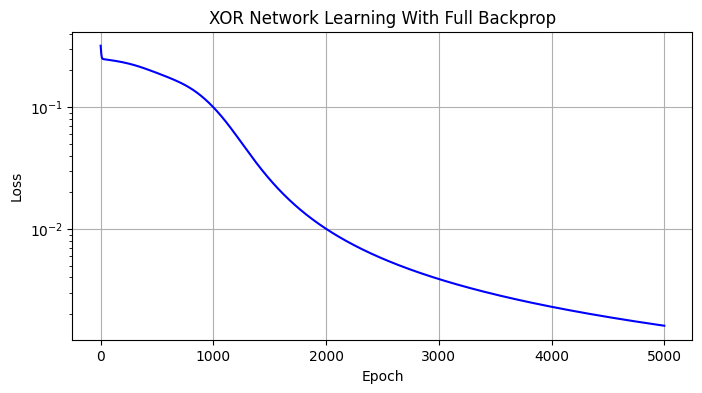

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, 'b-', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR Network Learning With Full Backprop")
plt.yscale('log')    # log scale shows the drop clearly
plt.grid(True)
plt.show()

In [ ]:
import torch
import torch.nn as nn

# Same XOR data — now as PyTorch tensors
X_t = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_t = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# Define the SAME network in PyTorch
model = nn.Sequential(
    nn.Linear(2, 3),    # W1, b1
    nn.Sigmoid(),
    nn.Linear(3, 1),    # W2, b2
    nn.Sigmoid()
)

loss_fn   = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

loss_history_pt = []

for epoch in range(5000):
    # Forward pass
    predictions = model(X_t)
    loss        = loss_fn(predictions, y_t)

    # Backward pass 
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute ALL gradients automatically ← THIS IS BACKPROP
    optimizer.step()        # update ALL weights ← THIS IS GRADIENT DESCENT

    loss_history_pt.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

print(f"\nFinal predictions:")
print(torch.round(model(X_t), decimals=3))


Epoch    0 | Loss: 0.269422
Epoch  500 | Loss: 0.249902
Epoch 1000 | Loss: 0.249044
Epoch 1500 | Loss: 0.232940
Epoch 2000 | Loss: 0.145839
Epoch 2500 | Loss: 0.028370
Epoch 3000 | Loss: 0.010381
Epoch 3500 | Loss: 0.005905
Epoch 4000 | Loss: 0.004028
Epoch 4500 | Loss: 0.003023

Final predictions:
tensor([[0.0510],
        [0.9530],
        [0.9520],
        [0.0500]], grad_fn=<RoundBackward1>)


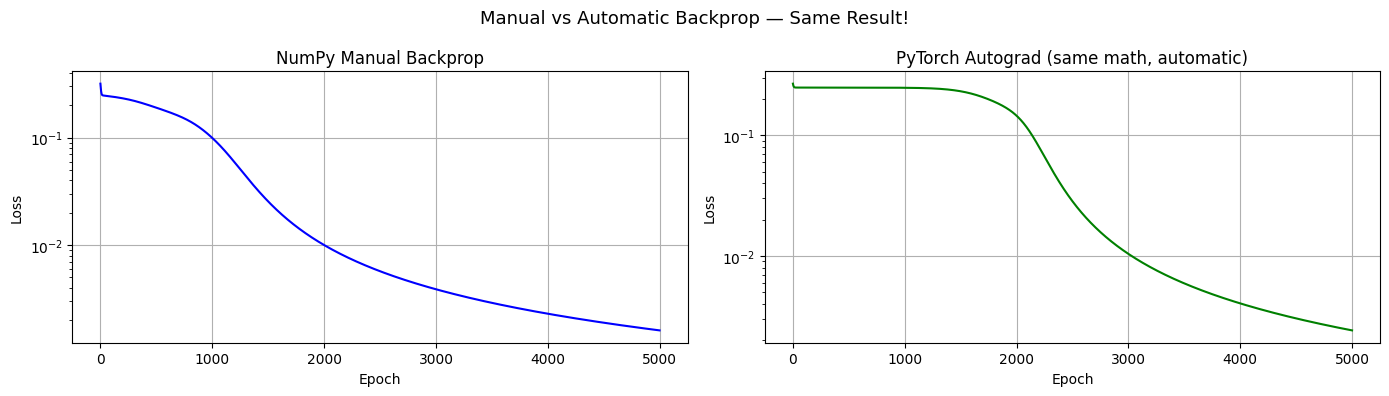

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(loss_history, 'b-', linewidth=1.5)
ax1.set_title("NumPy Manual Backprop")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_yscale('log')
ax1.grid(True)

ax2.plot(loss_history_pt, 'g-', linewidth=1.5)
ax2.set_title("PyTorch Autograd (same math, automatic)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_yscale('log')
ax2.grid(True)

plt.suptitle("Manual vs Automatic Backprop — Same Result!", fontsize=13)
plt.tight_layout()
plt.show()


In [5]:
# Example of PyTorch's computational graph in action
x = torch.tensor([2.0], requires_grad=True)
y = x ** 3 + 2 * x       # y = x³ + 2x

y.backward()              # computing dy/dx automatically

print(f"x = {x.item()}")
print(f"y = {y.item()}")
print(f"dy/dx computed by PyTorch: {x.grad.item()}")

# Manually: dy/dx = 3x² + 2
# At x=2: 3(4) + 2 = 14
print(f"dy/dx computed manually:   {3*(2**2) + 2}")
# They should match 


x = 2.0
y = 12.0
dy/dx computed by PyTorch: 14.0
dy/dx computed manually:   14
